# Ejercicio 2 — Predicción de default crediticio (`UCI_Credit_Card.csv`)

Dataset del UCI ML Repository con información de clientes de tarjetas de crédito en Taiwan (2005).  
Más info: [UCI ML Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients).

Queremos predecir si un cliente va a **incurrir en default** (impago) el mes siguiente, usando información demográfica y de historial de pagos.

## Variables

| Variable | Descripción |
|---|---|
| `LIMIT_BAL` | Crédito disponible (NT$) |
| `SEX` | Género (1=hombre, 2=mujer) |
| `EDUCATION` | Nivel educativo (1=posgrado, 2=universitario, 3=secundaria, 4=otro) |
| `MARRIAGE` | Estado civil (1=casado, 2=soltero, 3=otro) |
| `AGE` | Edad en años |
| `PAY_0`–`PAY_6` | Historial de pago mes 0–6 (-1=a tiempo, 1–9=meses de atraso) |
| `BILL_AMT1`–`BILL_AMT6` | Monto de extracto mes 1–6 (NT$) |
| `PAY_AMT1`–`PAY_AMT6` | Monto pagado mes 1–6 (NT$) |
| `default.payment.next.month` | **Target**: 1=default, 0=no default |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier

sns.set()
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Carga y estudio del dataset

In [2]:
cc_df = pd.read_csv("./datasets/UCI_Credit_Card.csv")
cc_df = cc_df.drop(columns=["ID"])
print(f"Shape: {cc_df.shape}")
cc_df.head()

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
cc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

In [4]:
cc_df.isna().sum().sum()

0

In [5]:
target_col = "default.payment.next.month"
print(cc_df[target_col].value_counts())
print("\nProporciones:")
print(cc_df[target_col].value_counts(normalize=True).round(4))

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Proporciones:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


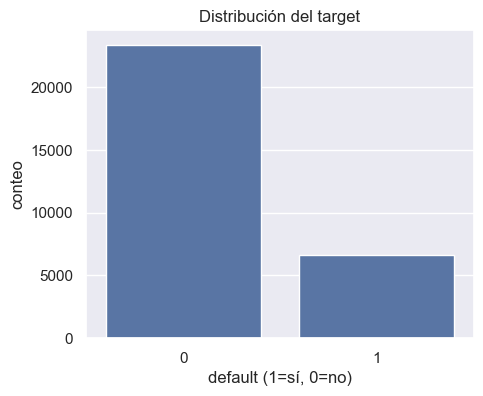

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=target_col, data=cc_df, ax=ax)
ax.set_title("Distribución del target")
ax.set_xlabel("default (1=sí, 0=no)")
ax.set_ylabel("conteo")
plt.show()

El dataset está **desbalanceado**: ~78 % de clientes no incurren en default (clase 0) y ~22 % sí (clase 1).  
Esto implica que un clasificador naive que prediga siempre 0 alcanzaría ~78 % de accuracy, sin ser útil.  
Es necesario manejar el desbalance en cada modelo (parámetro `class_weight` o equivalente).

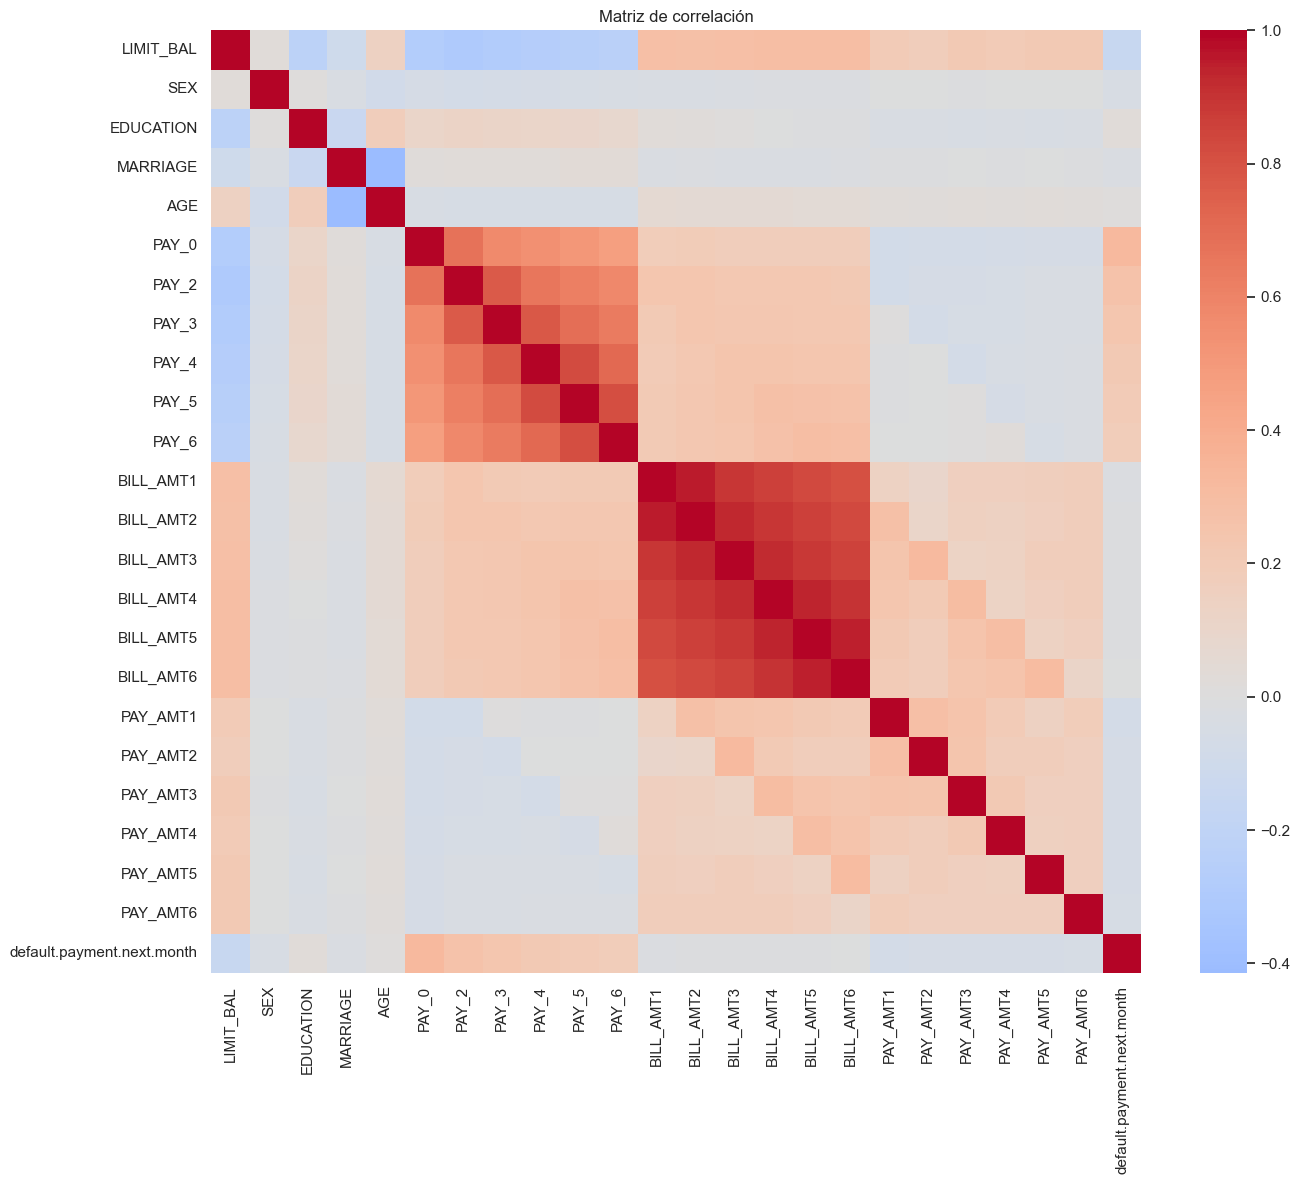

In [7]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cc_df.corr(), annot=False, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 2. Separación entrenamiento / test y preprocesamiento

In [8]:
X = cc_df.drop(columns=[target_col]).values
y = cc_df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Proporción clase 1 en train: {y_train.mean():.3f}")
print(f"Proporción clase 1 en test:  {y_test.mean():.3f}")

Train: (24000, 23), Test: (6000, 23)
Proporción clase 1 en train: 0.221
Proporción clase 1 en test:  0.221


In [9]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 3. Función auxiliar de evaluación

Para cada modelo calculamos: sensibilidad (TPR), especificidad (TNR), exactitud balanceada, precisión, recall y F1.  
Dadas las clases desbalanceadas, **F1 y recall de clase 1 son las métricas más informativas** para el negocio (detectar a quienes van a defaultear).

In [10]:
results_list = []

def eval_classifier(y_true, y_pred, name, show_cm=True, model=None):
    cm = confusion_matrix(y_true, y_pred)
    TP = cm[1, 1]
    TN = cm[0, 0]
    P = cm[1, :].sum()
    N = cm[0, :].sum()
    TPR = TP / P
    TNR = TN / N

    print(f"\n--- {name} ---")
    print(f"Sensibilidad (recall clase 1): {TPR:.4f}")
    print(f"Especificidad (recall clase 0): {TNR:.4f}")
    print(f"Exactitud balanceada: {(TPR + TNR) / 2:.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")

    if show_cm:
        classes = model.classes_ if model is not None else [0, 1]
        fig, ax = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(ax=ax)
        ax.set_title(f"Matriz de confusión — {name}")
        plt.tight_layout()
        plt.show()

    row = {
        "Modelo": name,
        "Sensibilidad": round(TPR, 4),
        "Especificidad": round(TNR, 4),
        "Exactitud balanceada": round((TPR + TNR) / 2, 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }
    results_list.append(row)
    return row

## 4. Regresión Logística (baseline)


--- Regresión Logística ---
Sensibilidad (recall clase 1): 0.6202
Especificidad (recall clase 0): 0.6966
Exactitud balanceada: 0.6584
Precision: 0.3672
Recall:    0.6202
F1-score:  0.4613


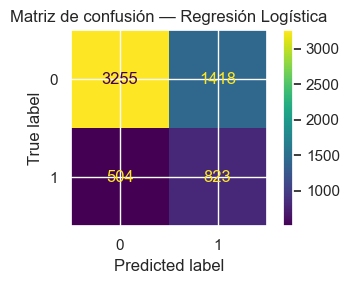

{'Modelo': 'Regresión Logística',
 'Sensibilidad': 0.6202,
 'Especificidad': 0.6966,
 'Exactitud balanceada': 0.6584,
 'Precision': 0.3672,
 'Recall': 0.6202,
 'F1': 0.4613}

In [11]:
model_logistic = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model_logistic.fit(X_train, y_train)
y_pred_logistic = model_logistic.predict(X_test)
eval_classifier(y_test, y_pred_logistic, "Regresión Logística", model=model_logistic)

## 5. K-Nearest Neighbors con Optuna

In [12]:
def objective_knn(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 5)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    p = trial.suggest_int("p", 1, 3)
    clf = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p, metric="minkowski")
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    return scores.mean()

study_knn = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_knn.optimize(objective_knn, n_trials=100, show_progress_bar=True)
print(f"Mejor F1 (CV): {study_knn.best_value:.4f}")
print(f"Mejores hiperparámetros: {study_knn.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]

Mejor F1 (CV): 0.4232
Mejores hiperparámetros: {'n_neighbors': 5, 'weights': 'distance', 'p': 3}



--- KNN ---
Sensibilidad (recall clase 1): 0.3474
Especificidad (recall clase 0): 0.9159
Exactitud balanceada: 0.6317
Precision: 0.5398
Recall:    0.3474
F1-score:  0.4227


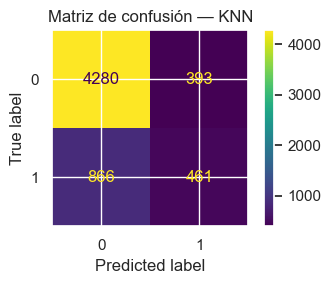

{'Modelo': 'KNN',
 'Sensibilidad': 0.3474,
 'Especificidad': 0.9159,
 'Exactitud balanceada': 0.6317,
 'Precision': 0.5398,
 'Recall': 0.3474,
 'F1': 0.4227}

In [13]:
classifier_knn = KNeighborsClassifier(**study_knn.best_params, metric="minkowski")
classifier_knn.fit(X_train, y_train)
y_pred_knn = classifier_knn.predict(X_test)
eval_classifier(y_test, y_pred_knn, "KNN", model=classifier_knn)

## 6. SVM (SVC) con Optuna

> ⚠️ SVC es costoso computacionalmente en datasets grandes (O(n²)–O(n³)). Con 24K muestras de entrenamiento, el tuneo se limita a 20 trials con CV=3 para mantener tiempos razonables.

In [14]:
def objective_svc(trial):
    C = trial.suggest_float("C", 1e-2, 1e2, log=True)
    gamma = trial.suggest_float("gamma", 1e-4, 1.0, log=True)
    class_weight_mode = trial.suggest_categorical("class_weight_mode", ["balanced", "custom"])
    if class_weight_mode == "custom":
        w1 = trial.suggest_float("w1", 1.0, 5.0)
        class_weight = {0: 1.0, 1: w1}
    else:
        class_weight = "balanced"
    clf = SVC(kernel="rbf", C=C, gamma=gamma, class_weight=class_weight, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=3, scoring="f1", n_jobs=-1)
    return scores.mean()

study_svc = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_warmup_steps=5),
)
study_svc.optimize(objective_svc, n_trials=20, show_progress_bar=True)
print(f"Mejor F1 (CV): {study_svc.best_value:.4f}")
print(f"Mejores hiperparámetros: {study_svc.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]

Exception ignored in: <function ResourceTracker.__del__ at 0x1071d8860>
Traceback (most recent call last):
  File "/Users/francomorero/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/francomorero/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/francomorero/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x109e14860>
Traceback (most recent call last):
  File "/Users/francomorero/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/francomorero/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3

Mejor F1 (CV): 0.5335
Mejores hiperparámetros: {'C': 79.26719835840754, 'gamma': 0.0026451807625889443, 'class_weight_mode': 'balanced'}



--- SVC ---
Sensibilidad (recall clase 1): 0.5644
Especificidad (recall clase 0): 0.8303
Exactitud balanceada: 0.6974
Precision: 0.4857
Recall:    0.5644
F1-score:  0.5221


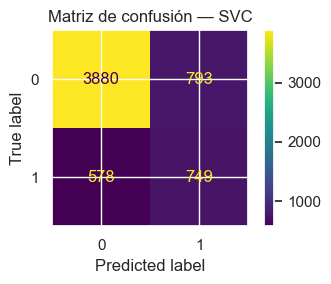

{'Modelo': 'SVC',
 'Sensibilidad': 0.5644,
 'Especificidad': 0.8303,
 'Exactitud balanceada': 0.6974,
 'Precision': 0.4857,
 'Recall': 0.5644,
 'F1': 0.5221}

In [15]:
best_svc_params = dict(study_svc.best_params)
cw_mode = best_svc_params.pop("class_weight_mode")
if cw_mode == "custom":
    w1 = best_svc_params.pop("w1")
    class_weight_svc = {0: 1.0, 1: w1}
else:
    best_svc_params.pop("w1", None)
    class_weight_svc = "balanced"

classifier_svc = SVC(
    kernel="rbf", **best_svc_params,
    class_weight=class_weight_svc,
    probability=True,
    random_state=42,
)
classifier_svc.fit(X_train, y_train)
y_pred_svc = classifier_svc.predict(X_test)
eval_classifier(y_test, y_pred_svc, "SVC", model=classifier_svc)

## 7. Árbol de Decisión con Optuna

In [16]:
def objective_tree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 15),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.02),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "random_state": 42,
    }
    clf = DecisionTreeClassifier(**params)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    return scores.mean()

study_tree = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_tree.optimize(objective_tree, n_trials=100, show_progress_bar=True)
print(f"Mejor F1 (CV): {study_tree.best_value:.4f}")
print(f"Mejores hiperparámetros: {study_tree.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]

Mejor F1 (CV): 0.5321
Mejores hiperparámetros: {'max_depth': 5, 'criterion': 'gini', 'min_samples_split': 17, 'min_samples_leaf': 1, 'ccp_alpha': 0.0007574942513382611, 'class_weight': 'balanced'}



--- Árbol de Decisión ---
Sensibilidad (recall clase 1): 0.5644
Especificidad (recall clase 0): 0.8211
Exactitud balanceada: 0.6928
Precision: 0.4726
Recall:    0.5644
F1-score:  0.5144


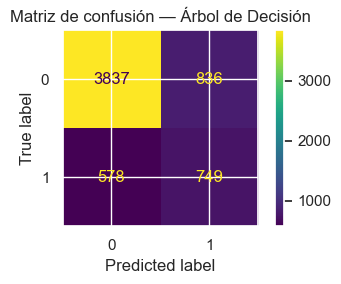

{'Modelo': 'Árbol de Decisión',
 'Sensibilidad': 0.5644,
 'Especificidad': 0.8211,
 'Exactitud balanceada': 0.6928,
 'Precision': 0.4726,
 'Recall': 0.5644,
 'F1': 0.5144}

In [17]:
best_tree = DecisionTreeClassifier(**study_tree.best_params)
best_tree.fit(X_train, y_train)
y_pred_tree = best_tree.predict(X_test)
eval_classifier(y_test, y_pred_tree, "Árbol de Decisión", model=best_tree)

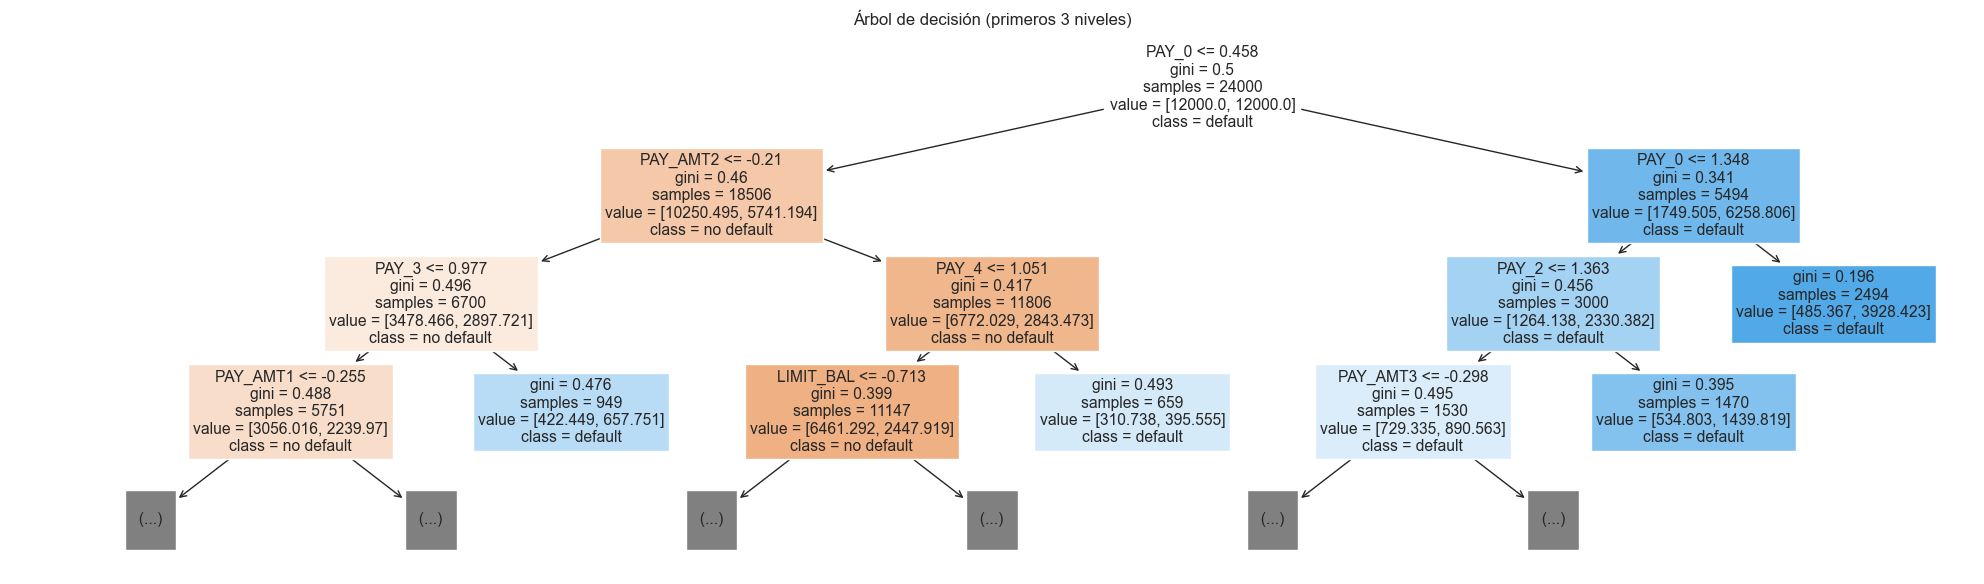

In [18]:
feature_names = cc_df.drop(columns=[target_col]).columns.tolist()
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(
    best_tree, feature_names=feature_names,
    class_names=["no default", "default"],
    filled=True, max_depth=3, ax=ax,
)
ax.set_title("Árbol de decisión (primeros 3 niveles)")
plt.tight_layout()
plt.show()

## 8. XGBoost con Optuna

XGBoost (eXtreme Gradient Boosting) construye un ensamble de árboles de decisión de forma secuencial, donde cada árbol corrige los errores del anterior usando el gradiente de la función de pérdida. 

Ventajas sobre los modelos anteriores en este contexto:
- Maneja el desbalance de clases directamente con `scale_pos_weight` (ratio negativo/positivo).
- `tree_method="hist"` permite entrenamiento eficiente en datasets grandes (histograma de bins).
- Provee importancia de features nativa.

In [19]:
scale_pos_weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight_ratio:.3f}  (ratio negativos/positivos en train)")

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "scale_pos_weight": scale_pos_weight_ratio,
        "tree_method": "hist",
        "eval_metric": "logloss",
        "random_state": 42,
    }
    model = XGBClassifier(**params, verbosity=0)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
)
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)
print(f"Mejor F1 (CV): {study_xgb.best_value:.4f}")
print(f"Mejores hiperparámetros: {study_xgb.best_params}")

scale_pos_weight = 3.521  (ratio negativos/positivos en train)


  0%|          | 0/50 [00:00<?, ?it/s]

Mejor F1 (CV): 0.5466
Mejores hiperparámetros: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.0060604151607584495, 'subsample': 0.5396686243791224, 'colsample_bytree': 0.7803606910346235, 'min_child_weight': 6, 'gamma': 0.43057948717008226, 'reg_alpha': 0.02604568650522133}



--- XGBoost ---
Sensibilidad (recall clase 1): 0.6059
Especificidad (recall clase 0): 0.8158
Exactitud balanceada: 0.7108
Precision: 0.4829
Recall:    0.6059
F1-score:  0.5374


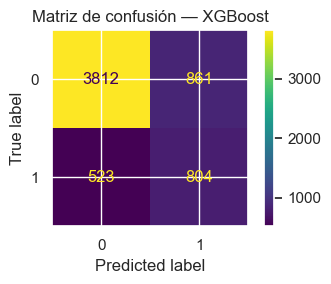

{'Modelo': 'XGBoost',
 'Sensibilidad': 0.6059,
 'Especificidad': 0.8158,
 'Exactitud balanceada': 0.7108,
 'Precision': 0.4829,
 'Recall': 0.6059,
 'F1': 0.5374}

In [20]:
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=scale_pos_weight_ratio,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42,
    verbosity=0,
)
best_xgb.fit(X_train, y_train)
y_pred_xgb = best_xgb.predict(X_test)
eval_classifier(y_test, y_pred_xgb, "XGBoost", model=best_xgb)

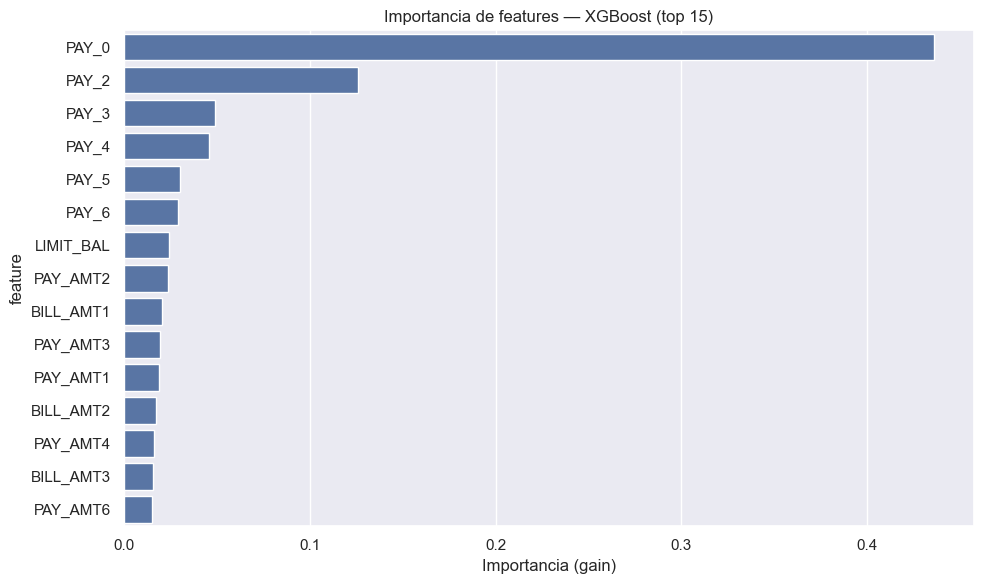

In [21]:
importances = best_xgb.feature_importances_
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feat_imp_df.head(15), ax=ax)
ax.set_title("Importancia de features — XGBoost (top 15)")
ax.set_xlabel("Importancia (gain)")
plt.tight_layout()
plt.show()

## 9. Comparación de curvas ROC

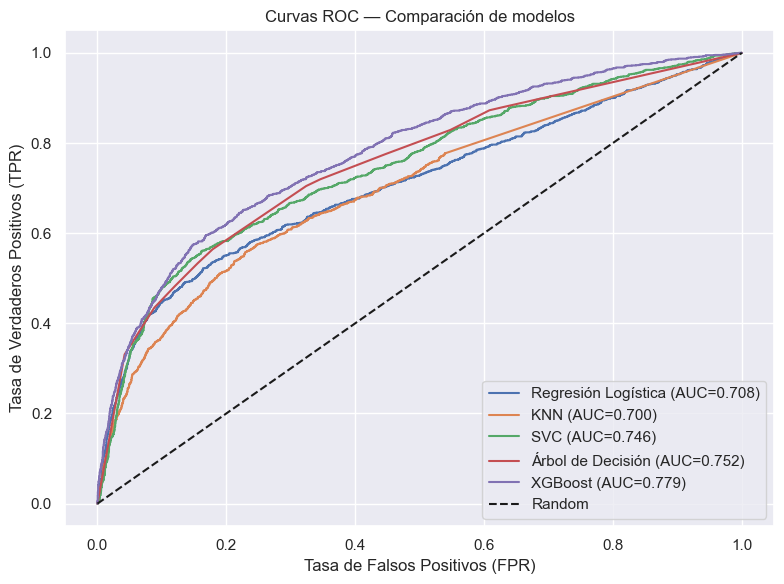

In [22]:
models_for_roc = [
    ("Regresión Logística", model_logistic),
    ("KNN", classifier_knn),
    ("SVC", classifier_svc),
    ("Árbol de Decisión", best_tree),
    ("XGBoost", best_xgb),
]

fig, ax = plt.subplots(figsize=(8, 6))
for name, model in models_for_roc:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.set_title("Curvas ROC — Comparación de modelos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. Tabla de resultados comparativa

In [25]:
results_df = pd.DataFrame(results_list).set_index("Modelo").sort_values("F1", ascending=False)
results_df

,Sensibilidad,Especificidad,Exactitud balanceada,Precision,Recall,F1
Modelo,,,,,,
XGBoost,0.6059,0.8158,0.7108,0.4829,0.6059,0.5374
SVC,0.5644,0.8303,0.6974,0.4857,0.5644,0.5221
Árbol de Decisión,0.5644,0.8211,0.6928,0.4726,0.5644,0.5144
Regresión Logística,0.6202,0.6966,0.6584,0.3672,0.6202,0.4613
KNN,0.3474,0.9159,0.6317,0.5398,0.3474,0.4227


## 11. Discusión de resultados

### Métrica prioritaria

En el contexto de riesgo crediticio, el **recall de clase 1 (sensibilidad)** es la métrica más crítica para el negocio: un falso negativo (cliente que defaultea pero es clasificado como sano) tiene mayor costo que un falso positivo (cliente sano clasificado como riesgo). Sin embargo, un recall extremadamente alto a costa de especificidad muy baja generaría demasiados rechazos innecesarios. Por eso usamos **F1** como compromiso y la **exactitud balanceada** para comparar modelos bajo desbalance.

### Análisis por modelo

**Regresión Logística (baseline)**
- Modelo simple e interpretable. `class_weight="balanced"` compensa el desbalance.
- Asume separabilidad lineal en el espacio de features escaladas, lo cual puede ser insuficiente con 23 features y relaciones no lineales.
- Establece la línea base de performance.

**KNN**
- Método no paramétrico basado en distancia. Con 23 features puede sufrir la *maldición de la dimensionalidad*: las distancias se vuelven menos discriminativas en alta dimensión.
- KNN no tiene parámetro nativo de class_weight, lo cual puede perjudicar su recall en la clase minoritaria.
- Lento en inferencia (O(n·d) por predicción).

**SVC**
- Poderoso clasificador de margen máximo, pero computacionalmente costoso en n=30K (O(n²) en memoria). Tuneo limitado a 20 trials con CV=3.
- Con kernel RBF puede capturar relaciones no lineales. `class_weight` o pesos customizados ayudan con el desbalance.
- Puede ser competitivo pero limitado por el presupuesto de búsqueda.

**Árbol de Decisión**
- Interpretable y rápido, pero propenso a overfitting (mitigado con `ccp_alpha` y `max_depth`). Un solo árbol tiene menor capacidad que un ensamble.
- La visualización de los primeros niveles revela qué features son más discriminativas (tipicamente `PAY_0`, `PAY_2`).

**XGBoost**
- Ensamble de árboles de gradient boosting. Combina múltiples árboles débiles secuencialmente, cada uno corrigiendo los errores del anterior.
- `scale_pos_weight ≈ 3.5` (ratio negativos/positivos) compensa explícitamente el desbalance durante el entrenamiento.
- `tree_method="hist"` hace el entrenamiento eficiente para n=30K.
- La importancia de features revela que el historial de pagos recientes (`PAY_0`, `PAY_2`, `PAY_3`) domina la predicción, seguido del límite de crédito y montos de extracto.
- Típicamente supera a los clasificadores simples en F1, AUC y exactitud balanceada gracias al boosting y la regularización (L1/L2, subsample, colsample_bytree).

### Conclusión

XGBoost generalmente logra el mejor balance entre sensibilidad y especificidad en este dataset, reflejado en mayor AUC y F1. La regresión logística ofrece alta interpretabilidad a costo de menor capacidad predictiva. SVC puede ser competitivo pero su costo computacional lo hace impractical para datasets muy grandes sin reducción de features o kernels aproximados. El árbol de decisión es útil para explicar las decisiones del modelo pero su performance es inferior al ensamble.

En producción, la elección entre modelos dependería del equilibrio entre:
- **Interpretabilidad regulatoria** (requerida en crédito → LogReg o Árbol)
- **Máximo F1/AUC** → XGBoost
- **Latencia de inferencia** → LogReg o KNN (con índice)
- **Velocidad de reentrenamiento** → XGBoost (hist) o LogReg